Tarea - Cloud Computing

* Ricardo Toro

# Imports

In [1]:
#%pip install --quiet pandasql statsmodels nbconvert ipynbname category_encoders

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from category_encoders import TargetEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error, mean_absolute_error
import statsmodels.api as sm

# Data Load

In [2]:
file = "C:/Users/tibox/OneDrive/Desktop/Magister Data Science/Curso 7 Cloud Computing/Proyecto_Final/MODELAMIENTO_MONTO_FRAUDE.csv"
df = pd.read_table(file, header=0, sep=";")
display(df)

,ID,MONTO_FRAUDE,FECHA_INICIAL,FECHA_DETECCION,N_OPERACIONES,TIPO_PRODUCTO,FLAG_CLIENTE_EMPRESA,N_FRAUDES_ANTERIORES
0,1,82982,01-01-2023,04-01-2023,1,TARJETA_CREDITO,0,0
1,2,819785,01-01-2023,03-01-2023,1,TARJETA_CREDITO,1,5
2,3,545622,01-01-2023,06-01-2023,3,TARJETA_DEBITO,1,5
3,4,96457,02-01-2023,05-01-2023,4,TARJETA_CREDITO,0,0
4,5,195487,02-01-2023,04-01-2023,5,TARJETA_CREDITO,0,0
...,...,...,...,...,...,...,...,...
7107,7108,22360,13-02-2023,16-02-2023,1,TARJETA_CREDITO,0,0
7108,7109,440760,13-02-2023,16-02-2023,3,TARJETA_CREDITO,0,8
7109,7110,566218,13-02-2023,15-02-2023,8,TARJETA_CREDITO,1,1
7110,7111,5284096,13-02-2023,15-02-2023,33,TARJETA_CREDITO,1,9


In [3]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7112 entries, 0 to 7111
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   ID                    7112 non-null   int64 
 1   MONTO_FRAUDE          7112 non-null   int64 
 2   FECHA_INICIAL         7112 non-null   object
 3   FECHA_DETECCION       7112 non-null   object
 4   N_OPERACIONES         7112 non-null   int64 
 5   TIPO_PRODUCTO         7112 non-null   object
 6   FLAG_CLIENTE_EMPRESA  7112 non-null   int64 
 7   N_FRAUDES_ANTERIORES  7112 non-null   int64 
dtypes: int64(5), object(3)
memory usage: 444.6+ KB


None

In [4]:
display(df.columns)

Index(['ID', 'MONTO_FRAUDE', 'FECHA_INICIAL', 'FECHA_DETECCION',
       'N_OPERACIONES', 'TIPO_PRODUCTO ', 'FLAG_CLIENTE_EMPRESA',
       'N_FRAUDES_ANTERIORES'],
      dtype='object')

In [9]:
# Cambiar nombre de la columna TIPO_PRODUCTO
df.rename(columns={'TIPO_PRODUCTO ': 'TIPO_PRODUCTO'}, inplace=True)

# Convertir fechas a datetime
df['FECHA_INICIAL'] = pd.to_datetime(df['FECHA_INICIAL'], format='%d-%m-%Y')
df['FECHA_DETECCION'] = pd.to_datetime(df['FECHA_DETECCION'], format='%d-%m-%Y')

display(df)

,ID,MONTO_FRAUDE,FECHA_INICIAL,FECHA_DETECCION,N_OPERACIONES,TIPO_PRODUCTO,FLAG_CLIENTE_EMPRESA,N_FRAUDES_ANTERIORES
0,1,82982,2023-01-01,2023-01-04,1,TARJETA_CREDITO,0,0
1,2,819785,2023-01-01,2023-01-03,1,TARJETA_CREDITO,1,5
2,3,545622,2023-01-01,2023-01-06,3,TARJETA_DEBITO,1,5
3,4,96457,2023-01-02,2023-01-05,4,TARJETA_CREDITO,0,0
4,5,195487,2023-01-02,2023-01-04,5,TARJETA_CREDITO,0,0
...,...,...,...,...,...,...,...,...
7107,7108,22360,2023-02-13,2023-02-16,1,TARJETA_CREDITO,0,0
7108,7109,440760,2023-02-13,2023-02-16,3,TARJETA_CREDITO,0,8
7109,7110,566218,2023-02-13,2023-02-15,8,TARJETA_CREDITO,1,1
7110,7111,5284096,2023-02-13,2023-02-15,33,TARJETA_CREDITO,1,9


# 1. Selección de las Muestras 
Se divide las muestras de entrenamiento y validación seleccionando aleatoriamente 70% para entrenamiento y 30% para validación.

In [10]:
# Split learning and validation datasets (Train: 0.7 y Test: 0.3)
np.random.seed(222) # Seed
p_train = 0.7 # % train set 
id_train = list(np.random.choice(df.shape[0], size=int(p_train * df.shape[0]), replace=False))
data_train = df.iloc[id_train].copy()
data_test = df.drop(id_train).copy()

In [11]:
display(data_train.shape, data_test.shape)


(4978, 8)

(2134, 8)

# 2. Análisis Descriptivo
Estadísticas descriptivas (tendencia central, percentiles y dispersión) y gráficos coherentes con las variables.

In [12]:
# Estadísticas descriptivas
display('Tendencia central, percentiles y dispersión:', data_train.drop(columns=['ID']).describe())

'Tendencia central, percentiles y dispersión:'

,MONTO_FRAUDE,FECHA_INICIAL,FECHA_DETECCION,N_OPERACIONES,FLAG_CLIENTE_EMPRESA,N_FRAUDES_ANTERIORES
count,4.978000e+03,4978,4978,4978.000000,4978.000000,4978.000000
mean,5.935404e+05,2023-03-01 13:50:30.132583424,2023-03-04 22:48:50.333467392,7.022097,0.145641,1.854962
min,1.025500e+04,2023-01-01 00:00:00,2023-01-03 00:00:00,1.000000,0.000000,0.000000
25%,7.879950e+04,2023-02-07 00:00:00,2023-02-10 06:00:00,2.000000,0.000000,0.000000
50%,1.460180e+05,2023-02-26 00:00:00,2023-03-01 00:00:00,4.000000,0.000000,0.000000
75%,4.385940e+05,2023-03-23 00:00:00,2023-03-27 00:00:00,5.000000,0.000000,3.000000
max,9.399692e+06,2023-04-30 00:00:00,2023-05-05 00:00:00,96.000000,1.000000,10.000000
std,1.485026e+06,NaN,NaN,13.977260,0.352781,3.115785


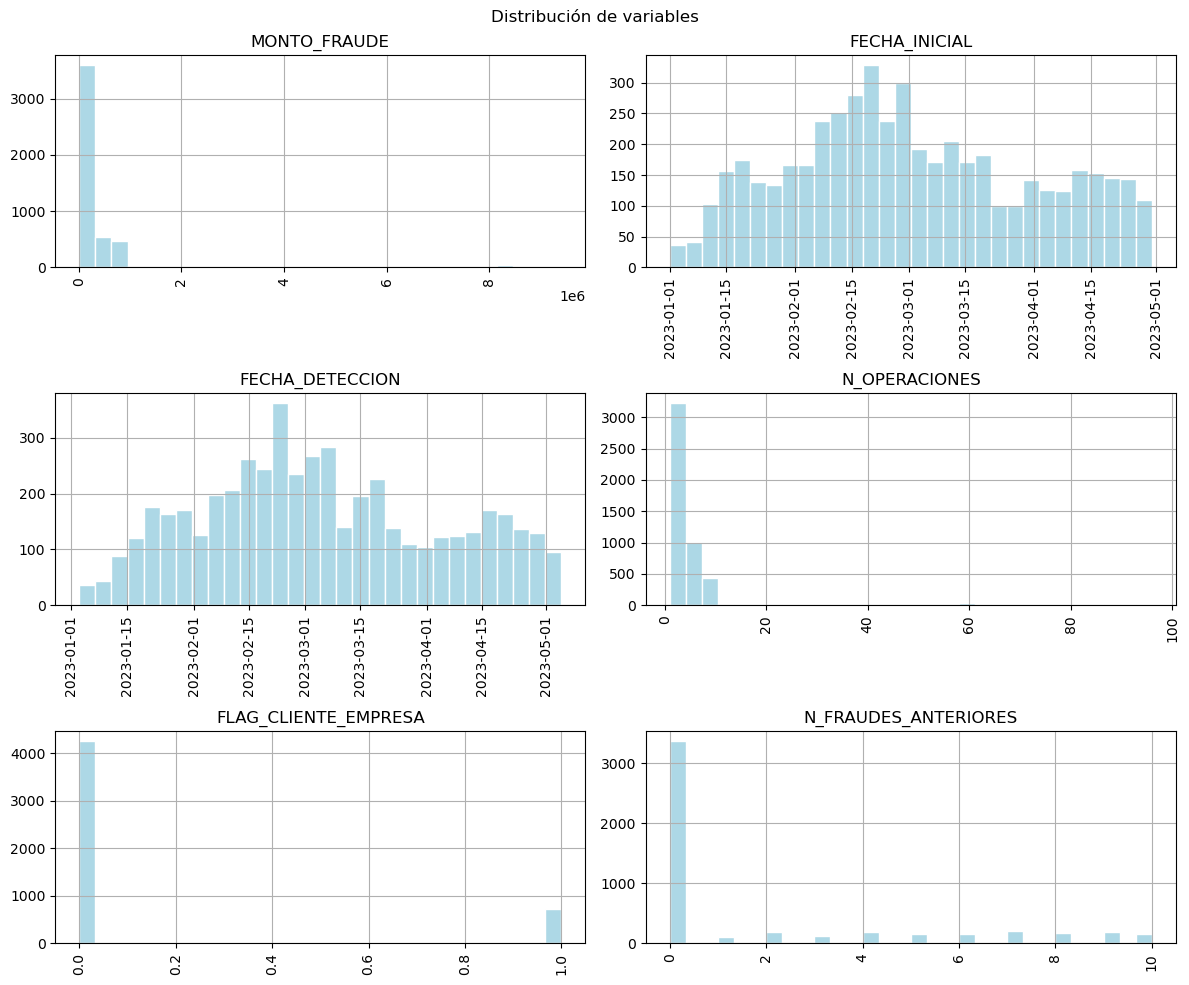

In [13]:
# Distribución
data_train.drop(columns=['ID']).hist(figsize=(12, 10), bins=30, color='lightblue', edgecolor='white') # Hist

plt.suptitle("Distribución de variables") # Titulo

# Rotar etiquetas X
for ax in plt.gcf().axes:
    ax.tick_params(axis='x', labelrotation=90)

plt.tight_layout()
plt.show()

Interpretaciones
* MONTO_FRAUDE:
  Distribución sesgada a la derecha. La mayoría de los fraudes son por montos bajos.


* FECHA_INICIAL y FECHA_DETECCION:
  Concentración de fechas en los meses febrero y marzo. Puede ser interesante indagar en si existe una explicación para que los fraudes se concentren en esos meses.
  Una posible nueva variable se podría construir a partir de la diferencia entre estas variables. 


* N_OPERACIONES:
  La mayoría de valores bajos, indicando que la mayoría de los clientes realizan pocas operaciones. Sería interesante profundizar si se tuviera datos como por ejemplo: de fecha de creación de la cuenta, dias de inactividad, que expliquen si las cuentas fueron creadas recientemente o destinadas exclusivamente a realizar fraude.


* FLAG_CLIENTE_EMPRESA:
  Mayoría de valores del tipo 0. Es decir, los fraudes son mayormente cometidos por tipo persona natural que de tipo empresa.


* N_FRAUDES_ANTERIORES:
  Mayor concentracion en cero casos anteriores. Lo que podría ser indicativo de que la mayoría de los fraudes son realizados por cuentas nuevas y/o se prefiere no utilizar repetidamente una cuenta para realizar fraude.

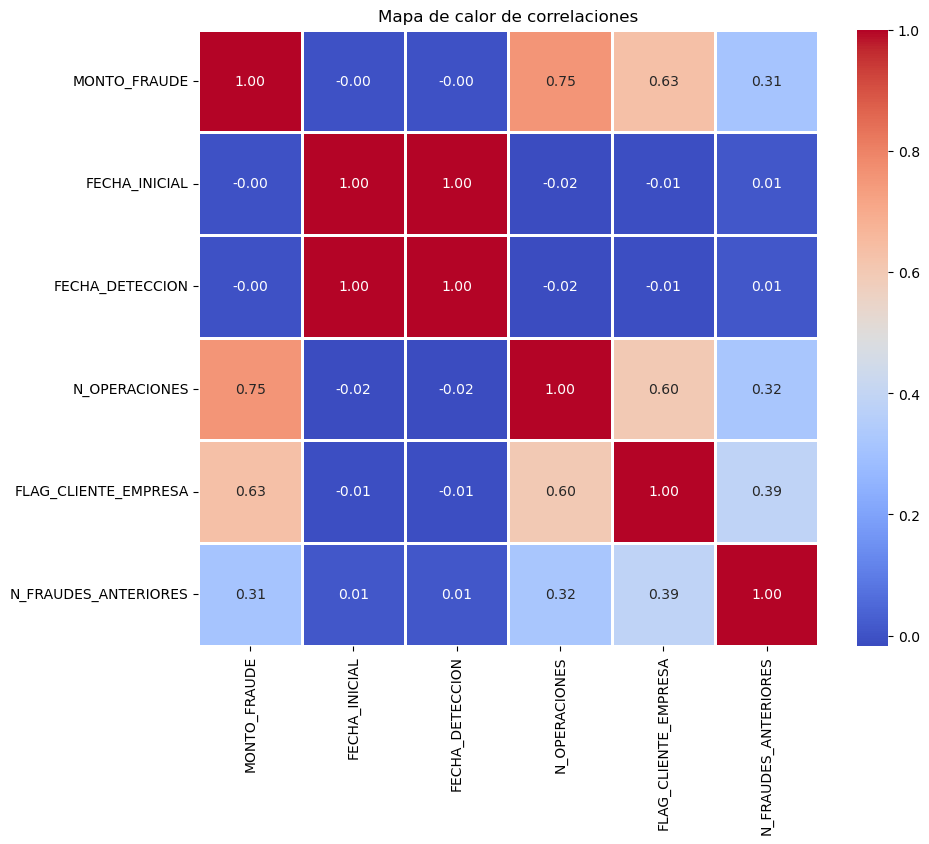

In [14]:
# Correlaciones
plt.figure(figsize=(10, 8))
sns.heatmap(data_train.drop(columns=['ID', 'TIPO_PRODUCTO']).corr(), annot=True, cmap='coolwarm', linecolor='white', linewidths=1, fmt=".2f")
plt.title("Mapa de calor de correlaciones")
plt.show()

Interpretaciones:

* MONTO_FRAUDE - N_OPERACIONES	(0.75):	
  Correlación positiva, más número de operaciones tiende a asociarse con fraudes de montos mayores.

* MONTO_FRAUDE - FLAG_CLIENTE_EMPRESA	(0.63):	
  Los clientes del tipo empresa tienden a realizar fraudes por monto mayores.

* FECHA_INICIAL - FECHA_DETECCION	(1.00):	
  Correlación perfecta, dada la naturaleza de los datos (sinteticos) se intuye que se debe a duplicar o contruir los datos de forma artificial.

* N_OPERACIONES - FLAG_CLIENTE_EMPRESA	(0.60):	
  Los clientes de tipo empresa realizan más operaciones.

* MONTO_FRAUDE - N_FRAUDES_ANTERIORES (0.31):	
  El número de fraudes anteriores tiene una leve asociación con el monto del fraude.

* FLAG_CLIENTE_EMPRESA - N_FRAUDES_ANTERIORES	(0.39):	
  Los clientes del tipo empresa tienen mayor número de fraudes anteriores.

# 3. Creación  y  Transformación  de  Variables
A  partir  de  la  muestra  de  entrenamiento,  he creado  variables  como por ejemplo: número de días del fraude, número de fraudes por día.

In [15]:
# Promedios por días hasta la detección del fraude
tmp_df = data_train.copy()
tmp_df['DIAS_DETECCION'] = (tmp_df['FECHA_DETECCION'] - tmp_df['FECHA_INICIAL']).dt.days
pd.pivot_table(tmp_df, index='DIAS_DETECCION', values='MONTO_FRAUDE', aggfunc='mean').astype(int)

,MONTO_FRAUDE
DIAS_DETECCION,
1,672133
2,605586
3,514908
4,699526
5,532447
6,515226


In [16]:
# Promedios por número de fraudes anteriores
tmp_df = data_train.copy()
pd.pivot_table(tmp_df, index='N_FRAUDES_ANTERIORES', values='MONTO_FRAUDE', aggfunc='mean').astype(int)

,MONTO_FRAUDE
N_FRAUDES_ANTERIORES,
0,204151
1,1616456
2,1338344
3,1340654
4,1642870
5,1663765
6,1730412
7,912576
8,1676329


In [17]:
# Promedios por tipo de producto y cliente
tmp_df = data_train.copy()
display(pd.pivot_table(tmp_df, index='TIPO_PRODUCTO', values='MONTO_FRAUDE', aggfunc='mean').astype(int))
display(pd.pivot_table(tmp_df, index='FLAG_CLIENTE_EMPRESA', values='MONTO_FRAUDE', aggfunc='mean').astype(int))
display(pd.pivot_table(tmp_df, index='TIPO_PRODUCTO', columns='FLAG_CLIENTE_EMPRESA', values='MONTO_FRAUDE', aggfunc='mean').astype(int))

,MONTO_FRAUDE
TIPO_PRODUCTO,
TARJETA_CREDITO,609547
TARJETA_DEBITO,484649


,MONTO_FRAUDE
FLAG_CLIENTE_EMPRESA,
0,204515
1,2875642


FLAG_CLIENTE_EMPRESA,0,1
TIPO_PRODUCTO,,
TARJETA_CREDITO,205016,2873202
TARJETA_DEBITO,201282,2899605


### Interpretación
Se observa en las tablas pivote anteriores, en primer lugar una diferencia en el promedio de la variable objetivo cuando se segmenta por tipo de producto, entre TARJETA_CREDITO y TARJETA_DEBITO. 
Posteriormente se observa también una diferencia pero mucho más marcada entre los registros de fraude segmentados por FLAG_CLIENTE_EMPRESA. 
Finalmente, si observamos los promedios segmentando tanto por producto como por tipo de cliente, se pierde la diferencia entre los promedios por tipo de producto, mostrando que esa diferencia era en realidad resultado de la cantidad desbalanceada de fraude que se realiza por tipo de producto para los clientes empresa.

## Creación de nuevas variables:

In [18]:
def transformar_columnas(input_df, encoders=None):
    if encoders is None:
        encoders = {}
    output_df = input_df.copy()

    # Obtener la diferencia en días entre las fechas
    output_df['DIAS_DETECCION'] = (output_df['FECHA_DETECCION'] - output_df['FECHA_INICIAL']).dt.days

    # Deteccion por día de la semana 
    output_df['DIA_SEMANA_INICIAL'] = output_df['FECHA_INICIAL'].dt.day_of_week
    output_df['DIA_SEMANA_DETECCION'] = output_df['FECHA_DETECCION'].dt.day_of_week
    output_df['DIA_SEMANA_INICIAL_CAT'] = output_df['DIA_SEMANA_INICIAL']
    output_df['DIA_SEMANA_DETECCION_CAT'] = output_df['DIA_SEMANA_DETECCION']

    output_df['DIAS_SEMANA'] = output_df['DIA_SEMANA_INICIAL_CAT'].astype(str) + output_df['DIA_SEMANA_DETECCION_CAT'].astype(str)

    # Drop las columnas de fecha
    output_df.drop(columns=['FECHA_INICIAL', 'FECHA_DETECCION'], inplace=True)

    # Discretización de N_OPERACIONES
    bins = [0, 5, 10, float('inf')]  # BAJO: (0–5], MEDIO: (5-10], ALTO: >10
    labels = ['BAJO', 'MEDIO', 'ALTO']
    output_df['N_OPERACIONES_CAT'] = pd.cut(output_df['N_OPERACIONES'], bins=bins, labels=labels, right=True)
    # One-Hot Encoding de N_OPERACIONES
    if encoders.get('one_hot') is None:
        encoders['one_hot'] = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
        encoders['one_hot'].fit(output_df[['N_OPERACIONES_CAT']])
    output_df[
        encoders['one_hot'].get_feature_names_out(['N_OPERACIONES_CAT'])
    ] = encoders['one_hot'].transform(output_df[['N_OPERACIONES_CAT']]).astype(int)

    # Fraude previo
    output_df['FRAUDE_PREVIO'] = output_df['N_FRAUDES_ANTERIORES'] > 0

    # Codificación de TIPO_PRODUCTO y FLAG_CLIENTE_EMPRESA
    output_df['TIPO_CLIENTE_PRODUCTO'] = output_df['TIPO_PRODUCTO'].astype(str) + '_' + output_df['FLAG_CLIENTE_EMPRESA'].astype(str)
    output_df['TIPO_CLIENTE_PRODUCTO_OPS'] = output_df['TIPO_CLIENTE_PRODUCTO'] + '_' + output_df['N_OPERACIONES_CAT'].astype(str)
    output_df['ALL_CATEGORIES'] = output_df['TIPO_CLIENTE_PRODUCTO_OPS'] + '_' + output_df['FRAUDE_PREVIO'].astype(str) + '_' + output_df['DIAS_SEMANA'].astype(str)
    # Target Encoding de TIPO_CLIENTE_PRODUCTO
    if encoders.get('target') is None:
        encoders['target'] = TargetEncoder(cols=['TIPO_PRODUCTO', 'FLAG_CLIENTE_EMPRESA', 'N_OPERACIONES_CAT', 'TIPO_CLIENTE_PRODUCTO', 'TIPO_CLIENTE_PRODUCTO_OPS', 'FRAUDE_PREVIO', 'DIA_SEMANA_INICIAL', 'DIA_SEMANA_DETECCION', 'DIAS_SEMANA', 'ALL_CATEGORIES'])
        encoders['target'].fit(output_df, output_df['MONTO_FRAUDE'])
    output_df = encoders['target'].transform(output_df)

    return output_df, encoders

data_train, encoders = transformar_columnas(data_train)
data_test, _ = transformar_columnas(data_test, encoders)

display(data_train)

,ID,MONTO_FRAUDE,N_OPERACIONES,TIPO_PRODUCTO,FLAG_CLIENTE_EMPRESA,N_FRAUDES_ANTERIORES,DIAS_DETECCION,DIA_SEMANA_INICIAL,DIA_SEMANA_DETECCION,DIA_SEMANA_INICIAL_CAT,DIA_SEMANA_DETECCION_CAT,DIAS_SEMANA,N_OPERACIONES_CAT,N_OPERACIONES_CAT_ALTO,N_OPERACIONES_CAT_BAJO,N_OPERACIONES_CAT_MEDIO,FRAUDE_PREVIO,TIPO_CLIENTE_PRODUCTO,TIPO_CLIENTE_PRODUCTO_OPS,ALL_CATEGORIES
4419,4420,55615,3,609547.967051,2.045153e+05,0,2,516349.459821,697906.879287,5,0,720163.800456,205988.733786,0,1,0,2.041517e+05,2.050165e+05,162512.707002,111479.220675
5071,5072,80837,2,609547.967051,2.045153e+05,0,4,454158.846591,697906.879287,3,0,307518.119301,205988.733786,0,1,0,2.041517e+05,2.050165e+05,162512.707002,129912.041490
3108,3109,80361,4,609547.967051,2.045153e+05,0,1,454158.846591,540216.776819,3,4,470345.956933,205988.733786,0,1,0,2.041517e+05,2.050165e+05,162512.707002,108964.659627
1277,1278,155272,4,484649.084639,2.045153e+05,0,4,599299.188180,380566.113636,4,1,566807.338325,205988.733786,0,1,0,2.041517e+05,2.012829e+05,186232.267552,349557.229932
6001,6002,253299,6,609547.967051,2.875643e+06,3,4,599299.188180,380566.113636,4,1,566807.338325,588648.760000,0,0,1,1.410360e+06,2.873203e+06,756593.764123,508568.576092
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3203,3204,102937,3,484649.084639,2.045153e+05,0,3,665022.467012,540216.776819,1,4,214621.667271,205988.733786,0,1,0,2.041517e+05,2.012829e+05,186232.267552,467665.621209
3624,3625,175945,5,609547.967051,2.045153e+05,0,2,665022.467012,790169.685583,1,3,751115.422622,205988.733786,0,1,0,2.041517e+05,2.050165e+05,162512.707002,92771.546540
2592,2593,46234,5,484649.084639,2.045153e+05,0,3,454158.846591,504507.111940,3,6,272325.235054,205988.733786,0,1,0,2.041517e+05,2.012829e+05,186232.267552,273799.157528
637,638,939319,3,609547.967051,2.045153e+05,4,4,454158.846591,697906.879287,3,0,307518.119301,205988.733786,0,1,0,1.410360e+06,2.050165e+05,162512.707002,565981.639637


In [19]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4978 entries, 4419 to 2732
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ID                         4978 non-null   int64  
 1   MONTO_FRAUDE               4978 non-null   int64  
 2   N_OPERACIONES              4978 non-null   int64  
 3   TIPO_PRODUCTO              4978 non-null   float64
 4   FLAG_CLIENTE_EMPRESA       4978 non-null   float64
 5   N_FRAUDES_ANTERIORES       4978 non-null   int64  
 6   DIAS_DETECCION             4978 non-null   int64  
 7   DIA_SEMANA_INICIAL         4978 non-null   float64
 8   DIA_SEMANA_DETECCION       4978 non-null   float64
 9   DIA_SEMANA_INICIAL_CAT     4978 non-null   int32  
 10  DIA_SEMANA_DETECCION_CAT   4978 non-null   int32  
 11  DIAS_SEMANA                4978 non-null   float64
 12  N_OPERACIONES_CAT          4978 non-null   float64
 13  N_OPERACIONES_CAT_ALTO     4978 non-null   int32  

Descripción de nuevas variables:
* DIAS_DETECCION: Diferencia de días entre FECHA_INICIAL y FECHA_DETECCION
* DIA_SEMANA_INICIAL: Promedio de MONTO_FRAUDE agrupado por día de la semana de FECHA_INICIAL
* DIA_SEMANA_DETECCION: Promedio de MONTO_FRAUDE agrupado por día de la semana de FECHA_DETECCION
* DIA_SEMANA_INICIAL_CAT: Valor numérico del día de la semana de FECHA_INICIAL
* DIA_SEMANA_DETECCION_CAT: Valor numérico del día de la semana de FECHA_DETECCION
* DIAS_SEMANA: Promedio de MONTO_FRAUDE agrupado por concatenación de DIA_SEMANA_INICIAL_CAT y DIA_SEMANA_DETECCION_CAT
* N_OPERACIONES_CAT: Promedio de MONTO_FRAUDE agrupado por categoría basada en rangos de N_OPERACIONES (BAJO: (0–5], MEDIO: (5-10], ALTO: >10)
* N_OPERACIONES_CAT_ALTO: One-Hot encoding de N_OPERACIONES_CAT
* N_OPERACIONES_CAT_BAJO: One-Hot encoding de N_OPERACIONES_CAT
* N_OPERACIONES_CAT_MEDIO: One-Hot encoding de N_OPERACIONES_CAT
* FRAUDE_PREVIO: Promedio de MONTO_FRAUDE agrupado por categorización de N_FRAUDES_ANTERIORES (valores iguales o distintos de cero)
* TIPO_CLIENTE_PRODUCTO: Promedio de MONTO_FRAUDE agrupado por concatenación de TIPO_PRODUCTO y FLAG_CLIENTE_EMPRESA
* TIPO_CLIENTE_PRODUCTO_OPS: Promedio de MONTO_FRAUDE agrupado por concatenación de TIPO_CLIENTE_PRODUCTO y N_OPERACIONES_CAT
* ALL_CATEGORIES: Promedio de MONTO_FRAUDE agrupado por concatenación de TIPO_CLIENTE_PRODUCTO_OPS, FRAUDE_PREVIO y DIAS_SEMANA

# 4. Modelamiento 
Desarrollo del modelo regresión lineal

In [20]:
def regresion_lineal(df, target, drop_cols=None):
    
    # Preparar datos
    if drop_cols is None:
      drop_cols = []
      
    X = df.drop(columns=drop_cols + [target])
    y = df[target]

    # Entrenar modelo
    model = LinearRegression()
    model.fit(X, y)

    # Predicción
    y_pred = model.predict(X)

    # Evaluación
    r2 = r2_score(y, y_pred)
    mse = mean_squared_error(y, y_pred)
    rmse = mse ** 0.5
    mape = mean_absolute_percentage_error(y, y_pred)
    mae = mean_absolute_error(y, y_pred)

    # Mostrar resultados
    print("\nMétricas Set Entrenamiento\n")
    print(f'R²: {r2:.4f}')
    print(f'MSE: {mse:.2f}')
    print(f'RMSE: {rmse:.2f}')
    print(f'MAPE: {mape:.4f}')
    print(f'MAE: {mae:.2f}')

    return {
        'model': model,
        'vars': X.columns,
        'r2': r2,
        'mse': mse,
        'rmse': rmse,
        'mae': mae,
        'mape': mape,
        'y_pred': y_pred
    }


Modelo con todas las variables

In [22]:
df = data_train
target = 'MONTO_FRAUDE'
drop_cols = ['ID'] # excluyendo ID

# Ejecutar modelo
modelo_5 = regresion_lineal(data_train, target, drop_cols)


Métricas Set Entrenamiento

R²: 0.8528
MSE: 324459573585.19
RMSE: 569613.53
MAPE: 1.0685
MAE: 231943.18


Se observa que para las métricas de R², MSE (Mean Squared Error), RMSE (Root Mean Squared Error) y MAPE (Mean Absolute Percentage Error), el modelo contiene todas las variables (menos la columna ID).